In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from esindy import fit_sindy, fit_esindy, SINDyConfig
from esindy.active_learning import ensemble_forecast, trajectory_uncertainty, active_learning_loop, generate_ic_pool
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt

### PySindy's job is to solve: $\dot{X} = \Theta(X) \cdot \Xi.$ 
$\Theta(X)$ is the **library matrix**. Every column is a **candidate function** evaluated at every available timepoint and $\Xi$ is the sparse coefficient matrix that PySindy solves for. As a starting example, the Lotka Volterra models predator/prey dynamics as a pair of first-order non-linear differential equations and thus the system has two state variables or species $[x,y]$. Given the model is well characterized, a realistic starting place for the library matrix is a second-order polynomial library with each column represeting the terms $[1,x,y,xy,x^2,y^2]$ and for which each row will be a timepoint. PySindy will then apply sparse linear regression in order to find the columns with nonzero coefficients that best capture the system dynamics.

In [3]:
# PySindy requires training data, typically observations of time series data
# Generate some synthetic species data, PySindy follows the convention (time, coordinate)
X = np.random.rand(100, 2) # 100 rows, 2 col (x,y)

# Instantiate second-order polynomial library
lib = ps.PolynomialLibrary(degree = 2, include_bias=False) # we have prior knowledge of the system, so we exclude bias terms (no intercepts)
lib.fit(X) # computes the number of output features

print(lib.get_feature_names_out()) # see default names
print(lib.transform(X).shape) # transform data to polynomial features
print(lib.n_output_features_) # see agreement between library definition and transformed data

['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']
(100, 5)
5


### Lotka Volterra Equations

$\frac{dx}{dt} = \alpha x - \beta xy$

$\frac{dy}{dt} = \gamma xy - \delta y$

Rewriting the differential equations in matrix form makes it easier to conceptualize the task PySindy is being assigned. Note the zeros in the matrix $\Xi$ which for this small system doesn't appear all that sparse but is sufficient for capturing the necessity of regularization, otherwise erroneous terms will end up being included.

$\frac{d}{dt}\begin{bmatrix} x \\ y \end{bmatrix} = \underbrace{\begin{bmatrix} \alpha & 0 & -\beta & 0 \\ 0 & -\delta & \gamma & 0 \end{bmatrix}}_{\Xi^T} \underbrace{\begin{bmatrix} x \\ y \\ xy \\ \cdots \end{bmatrix}}_{\theta(x,y)}$

Next we'll use the lotka volterra system defined in /target_systems/lotka_volterra.py to practice reading PySindy's output equations


In [4]:
from esindy.target_systems import LotkaVolterra

# initialize the class with random floats
seed = 123
rng = np.random.default_rng(seed)
alpha,beta,gamma,delta = rng.integers(low=1, high=5, size=4)
lv = LotkaVolterra(alpha, beta, gamma, delta) 
t_eval = np.linspace(0,50,10000) 

# simulation method inherited by all target systems, defaults described below
# NOTE: system is stiff when it has dynamics operating on very different timescales simultaneously
# thus LSODA was selected as the default ODE solver algorithm since it auto-switches between 
# stiff and non-stiff solvers, which should work well for biochemical systems which are often stiff
# y0 defines the initial conditions
# r_tol and a_tol are relative and absolute tolerance for error at each step and preventing zero-division, respectively
# dense_output=False b/c t_eval already specifies where we want output, otherwise solve_ivp returns 
# continuous interpolating solution between timepoints

X = lv.simulate(y0=np.array([2.0, 8.0]), t_span=(t_eval[0], t_eval[-1]), t_eval=t_eval) 



In [5]:
from esindy import fit_sindy, SINDyConfig

# we'll now demonstrate use of the SINDyConfig dataclass which
# bundles the essentials for PySINDY model construction: 
# candidate function library, coefficient matrix optimizer and differentiator 
# defaults: 
# Library: we assume we'll always some form of a polynomial library
# Optimizer: leveraging sequentially thresholded least squares to iteratively zero coefficients below 'threshold' and then refit
# threshold enables control over the sparsity of the matrix, too high -> lose real terms, too low -> overfit noise
# alpha -> ridge regularization strength for penalizing large coefficients; max_iter -> how many threshold-and-refit cycles
# Differentiator: finite_difference —> centered differences for even order and left-off-centered differences for odd order, can be sensitive to noise
# smoothed_finite_difference -> smooths input data first, then differentiates, uses savgol_filter as default 
# and is expected to perform better on biological data which is typically noisy

# here we just use SINDuConfig to specify changes to some defaults
config = SINDyConfig(poly_degree=2, include_bias=False, threshold=0.05, feature_names=["X", "Y"]) # leaving STLSQ and smoothed_finite_difference defaults

# right now fit_sindy appears redundant but will be useful later for 
# running the active learning training loop with a consistent interface 
# b/c it automatically transforms the coefficient matrix and bundles config
# return a SINDyResult data with model and coefficients resulting from the model instantiated accroding to config
result = fit_sindy(X, t_eval, config) 

print(result.model)
print('\nFunctional Form:')
result.model.print()                          # "human-readable" output
print('\nRaw Matrix:')
print(result.model.coefficients())            # raw matrix, shape (n_species, n_library_terms)


SINDy(differentiation_method=SmoothedFiniteDifference(),
      feature_library=PolynomialLibrary(include_bias=False),
      optimizer=STLSQ(threshold=0.05))

Functional Form:
(X)' =  0.999 X + -2.996 X Y
(Y)' = -2.997 Y +  0.999 X Y

Raw Matrix:
[[ 0.99893031  0.          0.         -2.99644092  0.        ]
 [ 0.         -2.99658577  0.          0.99864388  0.        ]]


### Next, I want to be able to rebuild symbolic expressions from the coefficients SINDy learned. I use SymPy to accomplish this.

In [6]:
import sympy as sp

# can't assume the user defined state variables in config for interpretability
if config.feature_names is None:
    state_names = lib.get_feature_names_out()
else: 
    state_names = config.feature_names
    
feature_names = result.model.get_feature_names()

# each row corresponds to a state variable, each column corresponds to a library term,
# and the value is the coefficient for that term in the equation for that state variable
Xi = result.model.coefficients() 


def sindy_to_sympy(row, candidates, eq_name):
    # Section 1: build symbolic RHS from SINDy terms
    expr = 0
    for name, coef in zip(candidates, row):
        if abs(coef) > 1e-10:
            term = sp.sympify(name.replace(" ", "*"))
            expr += coef * term

    # Section 2: simplify the symbolic expression
    expr = sp.simplify(expr)
   
    # Section 3: wrap it as a full differential equation
    eq = sp.Eq(sp.Symbol(eq_name), expr)
    return eq

    

eq_X = sindy_to_sympy(Xi[0], feature_names, f"d{state_names[0]}/dt")
eq_Y = sindy_to_sympy(Xi[1], feature_names, f"d{state_names[1]}/dt")

display(eq_X)
display(eq_Y)

Eq(dX/dt, X*(0.99893030706754 - 2.99644092481576*Y))

Eq(dY/dt, Y*(0.998643883728148*X - 2.99658577137194))

### Evaluating a SINDy Model
From the equations above, we see we recover the expected governing dynamical equations. In the following cell we simulate forwards and plot ground true vs predicted. Below that, we test .score() which, depending on the sklearn metric chosen (squared errored in the default), allows the SINDy model to return a some score; depends on .predict(). 

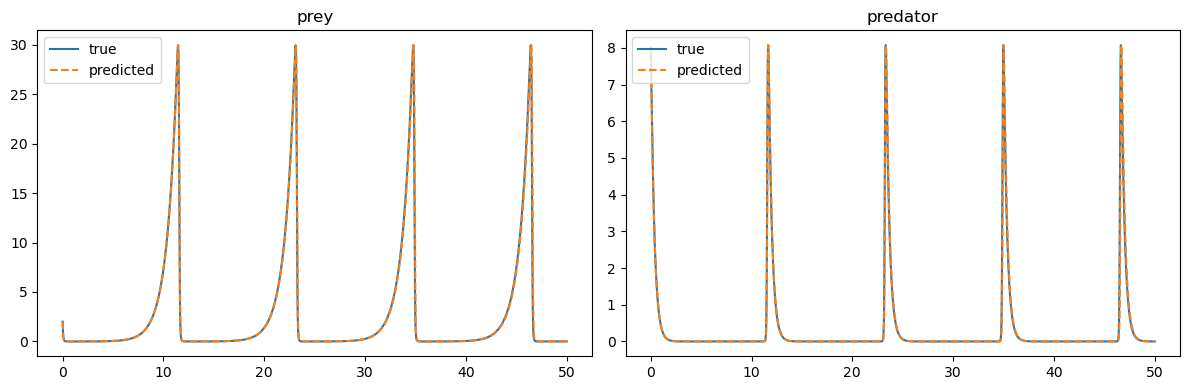

In [7]:
# same initial conditions
x0 = np.array([2.0, 8.0])
t_forward = np.linspace(0, 50,10000)

# use the fit model to simulate over same time range
X_pred = result.model.simulate(x0, t_forward)

# visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (ax, name) in enumerate(zip(axes, lv.species_names)):
    ax.plot(t_eval, X[:, i], label="true")
    ax.plot(t_forward, X_pred[:, i], '--', label="predicted")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()

In [8]:
# same initial conditions
x0 = np.array([2.0, 8.0])
t_forward = np.linspace(0, 50,10000)

# use the fit model to simulate over same time range
X_pred = result.model.predict(X)
print(X_pred)
print(f'R**2 value: {result.model.score(X, t_eval)}') # R^2 score of the model on the training data



[[-4.59451942e+01 -7.99438403e+00]
 [-4.07299692e+01 -9.67188890e+00]
 [-3.60943586e+01 -1.11245649e+01]
 ...
 [ 9.36647443e-03 -1.19443901e-03]
 [ 9.41354053e-03 -1.17669125e-03]
 [ 9.46084146e-03 -1.15920738e-03]]
R**2 value: 0.999995320755645


## SINDy-PI (Parallel Implicit SINDy)
### Standard explicit SINDy assumes a model of the form : 
$$\dot{\mathbf{x}} = \Theta(\mathbf{x}) \Xi$$

where the time derivative is represented as a sparse linear combination of candidate functions of the state alone. This works well for polynomial or otherwise explicit right-hand sides, but biochemical kinetics often contain rational terms such as Michaelis-Menten expressions,
$\dot{x} = \frac{x}{x + K_m}$ which are not naturally sparse in a polynomial library.

### Implicit formulation:
Implicit SINDy instead builds a library $\Theta(X, \dot{X})$ that includes both state and derivative terms, then solves the implicit system:

$$\Theta(X, \dot{X}) = \Theta(X, \dot{X})\Xi \quad \text{s.t.} \quad \Xi_{jj} = 0$$

The diagonal constraint $\Xi_{jj} = 0$ prevents the trivial solution $\Xi = I$, which would  simply predict each derivative from itself. If at least one term $\theta_j(x, \dot{x}) \in \Theta(x, \dot{x})$ is known, the implicit problem can be rewritten in explicit form:

$$\theta_j(X, \dot{X}) = \Theta(X, \dot{X}|\theta_j)\xi_j$$

where $\Theta(X, \dot{X}|\theta_j)$ is the library with the $\theta_j$ column removed and $\xi_j$ is the corresponding sparse coefficient vector. Note this is no longer implicit so we can solve with previously developed SINDy techniques and in this case we match the author's of SINDyPI and implement STLSQ. SINDy-PI runs this in parallel for each candidate $\theta_j$, minimizing:

$$\|\theta_j(X, \dot{X}) - \Theta(X, \dot{X}|\theta_j)\xi_j\|_2 + \beta\|\xi_j\|_0$$

where $\beta$ is the sparsity promoting parameter. STLSQ serves as the relaxation of the 
non-convex $\ell_0$ term, iteratively zeroing entries of $\xi_j$ below threshold $\lambda$ 
and refitting until convergence, assembling the final $\Xi$ column by column.


### SINDy-PI, cvxpy and Constrained Optimization

**What is cvxpy?**  
cvxpy is a Python library for convex optimization. SINDy-PI uses it under the hood because the implicit formulation cannot be solved with simple thresholded least squares (STLSQ). Instead it solves a constrained optimization problem, which cvxpy dispatches to a numerical solver **most specialized to the problem type**.

**Which solver does CVXPY select?**  
cvxpy automatically selects the most specialized solver for the problem structure. The relevant classes for SINDy-PI are:

- **QP (Quadratic Programming)** — quadratic objective, linear constraints. This is the default  structure of SINDy-PI (minimize residual subject to diagonal normalization), and why CVXPY dispatches to OSQP by default.
- **SOCP (Second-Order Cone Programming)** — extends QP with second-order cone constraints. Relevant if L1 regularization is applied via `thresholder='l1'`, which can be recast as an SOCP.

CVXPY also supports LP, SDP, EXP, POW, and MIP problem classes, but these are not relevant here 
— SINDy-PI coefficients are continuous, constraints are linear, and there is no integer, semidefinite, or exponential structure in the problem. I got all this info from the cvxpy documentation (https://www.cvxpy.org/tutorial/solvers/index.html)


In [9]:
# make sure you have the cvxpy module installed, required to use SINDyPI
# if using conda env, run `conda install -c conda-forge cvxpy` in terminal
# then check the import below succeeds without error
from esindy.SINDy_PI import SINDyPI

### Michaelis-Menten example

$\frac{x_i}{K_m + x_i}$ Michelis-Menten term, half-saturates when $x_i = K_m$. Including these terms in a custom library will be essential for recapitulating the dynamics of biochemical reaction networks.

$\dot{x} = \frac{x}{x + K_m}$

can be rearranged to

$(K_m + x)\dot{x} - x = 0$

or equivalently

$K_m \dot{x} + x\dot{x} - x = 0$

which is linear in the candidate implicit terms $\{\dot{x},\, x\dot{x},\, x\}$. So it is a natural target for implicit sparse regression.

 
The total number of Michelis-Menten library terms will depend on the number of species in our system and the number of predefined coefficients: 

$\text{num of MM terms} = n_{\text{species}} \times |K_m\text{ candidates}|$

We may explore the possibiltiy of learning the coefficients, time allowing.

In [10]:
from scipy.integrate import solve_ivp
from pysindy.utils import enzyme, bacterial

# define parameters
r = 1
dt = 0.001
T = 4
t = np.arange(0, T + dt, dt)
t_span = (t[0], t[-1])
x0_train = [0.55]
x_train = solve_ivp(enzyme, t_span, x0_train, t_eval=t).y.T
print(x_train.shape)

(4002, 1)


In [11]:
# SINDyPILibrary is deprecated for version > 1.7. so we use PDELibrary with implicit_terms=True
# we first need to construct a custom library with the desired functions, then specify it in the config

# Initialize custom SINDy library so that we can have x_dot inside it.
library_func = [
    lambda x: x,
    lambda x, y: x * y,
    lambda x: x ** 2,
    lambda x, y, z: x * y * z,
    lambda x, y: x * y ** 2,
    lambda x: x ** 3,
    lambda x, y, z, w: x * y * z * w,
    lambda x, y, z: x * y * z ** 2,
    lambda x, y: x * y ** 3,
    lambda x: x ** 4,
]

library_func_names = [
    lambda x: x,
    lambda x, y: f"{x} * {y}",
    lambda x: f"{x}^2",
    lambda x, y, z: f"{x} * {y} * {z}",
    lambda x, y: f"{x} * {y}^2",
    lambda x: f"{x}^3",
    lambda x, y, z, w: f"{x} * {y} * {z} * {w}",
    lambda x, y, z: f"{x} * {y} * {z}^2",
    lambda x, y: f"{x} * {y}^3",
    lambda x: f"{x}^4",
]

custom_lib = ps.CustomLibrary(
    library_functions=library_func,
    function_names=library_func_names,
).fit(x_train)

# then we pass all the necessary info in the config, including the custom library and temporal grid (required for implicit terms)
config_pde = SINDyConfig(
    library_type="pde",                   # feature library
    library_functions=custom_lib,
    include_bias=True,
    implicit_terms=True,
    temporal_grid=t,
    optimizer="SINDyPI",                  # optimizer
    threshold=0.2,                       # coefficients below this are set to 0
    alpha=0.05,                            # ridge regularization strength for penalizing large coefficients
    max_iter=20,                          # maximum number of threshold-and-refit iterations
    diff_method="finite_difference",      # differentiator
    drop_endpoints=True,
)


mm = fit_sindy(x_train,t,config_pde)
mm.model.print()
mm.model.get_feature_names()

c:\Users\natha\miniconda3\envs\ASR\lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(1) =  5.212 x0 + -0.802 x0^2 + -0.910 x0^3 + -0.405 x0^4 +  2.376 x0_t +  2.136 x0x0_t +  1.022 x0^2x0_t +  0.370 x0^3x0_t
(x0) =  4.816 x0^2 + -0.750 x0_t +  5.583 x0x0_t
(x0^2) =  3.178 x0^3 + -0.691 x0x0_t +  2.964 x0^2x0_t
(x0^3) =  0.212 x0^2 +  1.103 x0^4
(x0^4) =  0.458 x0^3
(x0_t) =  0.315 1 + -1.622 x0 +  0.579 x0^3 +  0.450 x0^4 + -0.470 x0^2x0_t + -0.353 x0^3x0_t
(x0x0_t) = -0.565 x0^2
(x0^2x0_t) =  0.000
(x0^3x0_t) =  0.000
(x0^4x0_t) =  0.000


['1',
 'x0',
 'x0^2',
 'x0^3',
 'x0^4',
 'x0_t',
 'x0x0_t',
 'x0^2x0_t',
 'x0^3x0_t',
 'x0^4x0_t']

## SINDy-PI Model Selection and Validation Workflow

SINDy-PI generates one candidate model per library term. So model selection and validation will proceeds in three stages:

In [12]:
print("Output features:", mm.model.coefficients().shape)

for i in range(10):
    coefs = mm.model.coefficients()[i, :]
    sparsity = np.sum(coefs == 0) / len(coefs)
    print(f"Model {i}: sparsity={sparsity:.2%}, nonzero={np.sum(coefs != 0)}")

Output features: (10, 10)
Model 0: sparsity=20.00%, nonzero=8
Model 1: sparsity=70.00%, nonzero=3
Model 2: sparsity=70.00%, nonzero=3
Model 3: sparsity=80.00%, nonzero=2
Model 4: sparsity=90.00%, nonzero=1
Model 5: sparsity=40.00%, nonzero=6
Model 6: sparsity=90.00%, nonzero=1
Model 7: sparsity=100.00%, nonzero=0
Model 8: sparsity=100.00%, nonzero=0
Model 9: sparsity=100.00%, nonzero=0


**1. Derivative MSE → select winning model**  
For each candidate model $i$, evaluate the normalized derivative prediction error on the training data:

$$\text{Error}_i = \frac{\|\dot{X} - \hat{\dot{X}}_i\|_2}{\|\dot{X}\|_2}$$

Models with all-zero coefficients are excluded. The candidate with minimum error is selected.

In [13]:
from pysindy.utils import AxesArray, comprehend_axes

x_wrapped = AxesArray(x_train, comprehend_axes(x_train))

# remove endpoints — finite difference cannot compute derivatives at boundaries
X_dot_true = np.asarray(mm.model.differentiation_method(x_wrapped, t=t)[1:-1])
X_dot_pred_all = np.asarray(mm.model.predict(x_train))[1:-1]

best_model_idx = None
best_error = np.inf

for i in range(10):
    coefs = mm.model.coefficients()[i, :]
    if np.all(coefs == 0):
        continue
    X_dot_pred = X_dot_pred_all[:, i]
    error = np.linalg.norm(X_dot_true.flatten() - X_dot_pred) / np.linalg.norm(X_dot_true.flatten())
    print(f"Model {i}: normalized error = {error:.4f}")
    if error < best_error:
        best_error = error
        best_model_idx = i

best_coefs = mm.model.coefficients()[best_model_idx, :]
print(f"\nBest model: {best_model_idx}, error: {best_error:.4f}")

Model 0: normalized error = 7.9127
Model 1: normalized error = 2.9139
Model 2: normalized error = 1.6843
Model 3: normalized error = 1.2941
Model 4: normalized error = 1.1355
Model 5: normalized error = 0.0257
Model 6: normalized error = 0.6197

Best model: 5, error: 0.0257


**2. SymPy → interpret the winning equation**  
Reconstruct the winning model's equation symbolically from its coefficient vector $\xi_j$ and library term names. This makes the implicit equation human-readable and allows algebraic manipulation.

In [14]:
import re

def name_to_sympy(name, symbol_map):
    """
    symbol_map: dict of string -> sympy symbol e.g. {'x0': x0, 'x0_t': x0_t}
    Tokens are longest-match first to avoid x0_t being parsed as x0.
    """
    if name == '1':
        return sp.Integer(1)
    
    # sort by length descending so x0_t is matched before x0
    tokens = sorted(symbol_map.keys(), key=len, reverse=True)
    pattern = '|'.join(re.escape(t) for t in tokens) + r'|\^(\d+)'
    
    expr = sp.Integer(1)
    i = 0
    name_work = name
    while name_work:
        matched = False
        for token in tokens:
            if name_work.startswith(token):
                sym = symbol_map[token]
                # check for exponent
                rest = name_work[len(token):]
                exp_match = re.match(r'^\^(\d+)', rest)
                if exp_match:
                    expr *= sym ** int(exp_match.group(1))
                    name_work = rest[exp_match.end():]
                else:
                    expr *= sym
                    name_work = rest
                matched = True
                break
        if not matched:
            raise ValueError(f"Could not parse token in: {name_work}")
    return expr


x0, x0_t = sp.symbols('x0 x0_t')
symbol_map = {'x0_t': x0_t, 'x0': x0} # longer keys first handled inside

feature_map = {name: name_to_sympy(name, symbol_map) 
               for name in mm.model.get_feature_names()}

best_coefs_rounded = np.round(best_coefs, 4)
expr = sum(coef * feature_map[name] 
           for name, coef in zip(mm.model.get_feature_names(), best_coefs_rounded)
           if abs(coef) > 1e-10)

eq = sp.Eq(x0_t, expr)
display(eq)



Eq(x0_t, 0.4495*x0**4 - 0.3533*x0**3*x0_t + 0.5793*x0**3 - 0.4705*x0**2*x0_t - 1.6224*x0 + 0.3154)

In [15]:
solution = sp.solve(eq, x0_t)[0]
display(sp.Eq(x0_t, solution))

# make sure the solution is in terms of x0 only, not x0_t
print(solution.free_symbols)

Eq(x0_t, (4495.0*x0**4 + 5793.0*x0**3 - 16224.0*x0 + 3154.0)/(3533.0*x0**3 + 4705.0*x0**2 + 10000.0))

{x0}


**3. Solve for $\dot{x}$ → integrate forward → full trajectory validation**  
Rearrange the implicit equation algebraically to isolate $\dot{x}$, then pass to `solve_ivp` to simulate forward from a held-out initial condition. Evaluate full trajectory MSE against the true system.

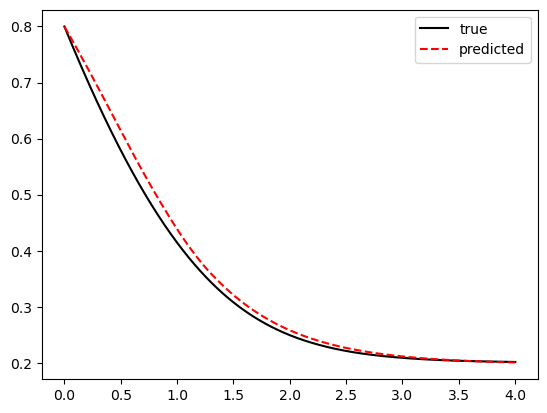

In [16]:
# convert sympy expression to a numeric function
rhs = sp.lambdify(x0, solution, 'numpy')

# simulate forward
x0_test = [0.8]  # different initial condition from training
t_test = np.arange(0, 4 + dt, dt)

span = (t_test[0], t_test[-1])
sol = solve_ivp(
    lambda t, x: rhs(x[0]),
    t_span=span,
    y0=x0_test,
    t_eval=t_test,
    method='LSODA'
)

# compare against true
x_true = solve_ivp(enzyme, (t_test[0], t_test[-1]), x0_test, t_eval=t_test).y.T

plt.plot(t_test, x_true, 'k', label='true')
plt.plot(t_test, sol.y.T, 'r--', label='predicted')
plt.legend()

#### So far we've validated vanilla SINDy with the Lotka Volterra model, and (after rectifying the pysindy package's SINDyPI implementation to be more faithful to the algorithm outlined in **SINDy-PI: a robust algorithm for parallel implicit sparse identification of nonlinear dynamics** by Kaheman et. al) SINDyPI with a simple Michelis-Menten example. We now seek to leverage E-SINDy and more specifically E-SINDyPI in an attempt to recover the governing dynamical equations for a model of the HPT axis, sourced from **Dynamics of thyroid diseases and thyroid-axis gland masses** by Kohanim et. al

## Active Learning with E-SINDyPI

The active learning loop follows the framework of Fasel et al. (2022), adapted for implicit dynamics via SINDy-PI and applied to the analytical and noisy trajectories modeling dynamics of the hypothalamic-pituitary-thyroid (HPT) axis.

**Initialization**
A random set of $n_{\text{init}}$ initial conditions is drawn from the pool, simulated via the HPT oracle, and concatenated into an initial labeled dataset.

**Query selection** (repeat until convergence or $n_{\text{queries}}$ reached):

1. **Fit E-SINDy-PI** on the current labeled set. Using `EnsembleOptimizer` we wrap either `SINDyPI` or `SINDy` as the base optimizer, bagging over trajectories to produce an ensemble of implicit sparse models. Inclusion probabilities $p_j \in [0,1]$ are computed per library term across bootstrap members.

2. **Query strategy**: for each candidate IC in the remaining pool, evaluate ensemble derivative variance at that IC. Then select the IC with highest uncertainty across committee members to be labeled and added to the dataset.

3. **Oracle query**: simulate the selected IC via `HPTAxis.simulate()` and concatenate to labeled set.

4. **Stopping condition**: stop when inclusion probabilities converge across a sliding window of iterations

**Validation** (every $N$ iterations and at convergence):

1. Select the best candidate model via normalized derivative MSE
2. Reconstruct the implicit equation symbolically via SymPy
3. Solve algebraically for $\dot{x}$, simulate forward via `solve_ivp`
4. Evaluate trajectory RMSE against held-out ground truth

In [3]:
# type: ignore[import]
from biomolecular_controllers.simulation import SimulationRunner
from biomolecular_controllers.model_library import Models
from biomolecular_controllers.model_library import DEFAULT_PARAMS, DEFAULT_INITIAL_CONDITIONS
from esindy.target_systems.hpt_axis import HPTAxis
from esindy.active_learning import active_learning_loop, generate_ic_pool

models = Models()
runner = SimulationRunner()
converter = HPTAxis()
print('Setup complete. Available models:', models.available_models)

Setup complete. Available models: ['HPT_dimensionless', 'HPT_full', 'HPT_dimensionless_PI_1', 'HPT_dimensionless_PPI', 'PC', 'PD_1', 'PD_2', 'PI_1', 'PI_2', 'PID_1', 'PID_2']


$$\text{uncertainty}(x_0) = \text{Var}_{\text{ensemble}}\left[\hat{\dot{X}}(x_0)\right]$$
$$\text{std}_{w}\left[p_j^{(q)}\right] < \tau \quad \forall j$$

In [4]:
# define ranges for initial condition to sample from for active learning
ic_ranges = {
    'x1': (0, 50),     # TRH  pg/mL
    'x2': (0, 100),    # TSH  mIU/L
    'x3': (0, 50),     # T4   pmol/L
    'P_mass': (0, 5),  # pituitary mass  g
    'T_mass': (0, 30), # thyroid mass    g
}

seed = 67 # hehehe
n_candidates = 50
rng = np.random.default_rng(seed)
ic_pool = []

# build pool of initial conditions by sampling uniformly
for _ in range(n_candidates):
    ic = {k: float(rng.uniform(low, high)) for k, (low, high) in ic_ranges.items()}
    ic_pool.append(ic)


In [6]:
config_multi = SINDyConfig(
    poly_degree=2,
    include_bias=True,
    optimizer="STLSQ",
    threshold=1e-9,
    feature_names=['TRH', 'TSH', 'T4', 'P_mass', 'T_mass'],
)

X_list = []
t_list = []
for ic in ic_pool[:5]:  # just 5 ICs
    s = runner.run_deterministic('HPT_full', t_span=(0, 3e6), points=500, params=None, ic=ic)
    X_ic, t_ic = converter.hpt_to_sindy(s)
    X_list.append(X_ic)
    t_list.append(t_ic)

n_transient = 200  # first 200 timepoints
result_multi = fit_sindy(X_list[:n_transient], t_list[:n_transient], config_multi)
result_multi.model.print()

(TRH)' =  0.000
(TSH)' =  0.000
(T4)' =  0.000
(P_mass)' =  0.000
(T_mass)' =  0.000


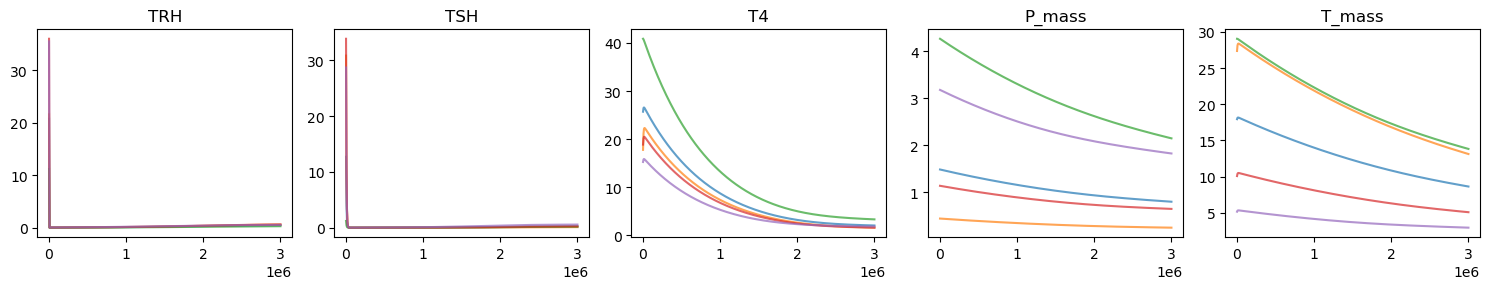

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
species = ['TRH', 'TSH', 'T4', 'P_mass', 'T_mass']

for X_ic, t_ic in zip(X_list, t_list):
    for i, (ax, name) in enumerate(zip(axes, species)):
        ax.plot(t_ic, X_ic[:, i], alpha=0.7)
        ax.set_title(name)

plt.tight_layout()

In [ ]:
config = SINDyConfig(
    poly_degree=1,
    include_bias=False,
    optimizer="STLSQ",
    threshold=1e-8,
    use_ensemble=True,
    n_models=10,
    feature_names=['TRH', 'TSH', 'T4', 'P_mass', 'T_mass'],
)

al_result = active_learning_loop(
    runner=runner,
    params=None,
    ic_pool=ic_pool,
    n_init=2,
    n_queries=3,
    t_span=(0, 3e6),
    points=300,
    n_test=3,
    eval_every=3,
    config=config,
    seed=42,
)

Query 1: score=0.0001, kept 95/300 timepoints
  [ensemble_forecast] Phase 1: solving sympy for 10 members...
Query 2: score=0.0000, kept 60/300 timepoints
  [ensemble_forecast] Phase 1: solving sympy for 10 members...
Query 3: score=0.0000, kept 60/300 timepoints
  [ensemble_forecast] Phase 1: solving sympy for 10 members...


### Uncertainty decay

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(al_result['scores_history']) + 1), 
         al_result['scores_history'], 'o-', color='steelblue')
plt.xlabel('Query')
plt.ylabel('Uncertainty Score')
plt.title('Ensemble Uncertainty Decay Over Queries')
plt.tight_layout()

### Inclusion probability heatmap

In [ ]:
prob_array = np.array(al_result['prob_history'])  # (n_queries, n_lib, n_species)
n_queries, n_lib, n_species = prob_array.shape
lib_names = al_result['results'][0].model.get_feature_names()
species = config.feature_names or [f'x{i}' for i in range(n_species)]

fig, axes = plt.subplots(1, n_species, figsize=(4 * n_species, 5), sharey=True)
for k, (ax, name) in enumerate(zip(axes, species)):
    im = ax.imshow(prob_array[:, :, k].T, aspect='auto',
                   vmin=0, vmax=1, cmap='viridis', origin='lower')
    ax.set_xlabel('Query')
    ax.set_title(f'd{name}/dt')
    ax.set_yticks(range(n_lib))
    ax.set_yticklabels(lib_names, fontsize=7)
    ax.set_xticks(range(n_queries))
    ax.set_xticklabels(range(1, n_queries + 1))
plt.colorbar(im, ax=axes[-1], label='Inclusion Probability')
plt.suptitle('Inclusion Probability Convergence')
plt.tight_layout()

### Trajectory recovery on test pool

In [ ]:
from esindy.SINDyPI_solve import simulate_sindy_pi

final_model = al_result['results'][-1].model
test_pool = al_result['test_pool']
t_eval = np.linspace(0, 3e6, 300)
n_plot = min(3, len(test_pool))

fig, axes = plt.subplots(n_plot, len(species), figsize=(4 * len(species), 3 * n_plot))
for row, ic in enumerate(test_pool[:n_plot]):
    s = runner.run_deterministic('HPT_full', t_span=(0, 3e6), points=300, params=None, ic=ic)
    X_true, t_true = converter.hpt_to_sindy(s)
    x0 = X_true[0]
    pred = simulate_sindy_pi(final_model, X_true, t_true, species, x0, t_eval)
    X_pred = pred['trajectory']
    for k, (ax, name) in enumerate(zip(axes[row], species)):
        ax.plot(t_true, X_true[:, k], 'k-', linewidth=1.5)
        if X_pred is not None:
            ax.plot(t_eval, X_pred[:, k], 'r--', linewidth=1.5)
        if row == 0: ax.set_title(name)
        if k == 0: ax.set_ylabel(f'IC {row+1}')
plt.suptitle('Trajectory Recovery — Test Pool')
plt.tight_layout()

### Active vs random 

In [ ]:
# run al_result_random with strategy='random' first
active_rmse = [...]   # populate from eval blocks
random_rmse = [...]

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(active_rmse) + 1), active_rmse, 'o-', color='steelblue', label='Active')
plt.plot(range(1, len(random_rmse) + 1), random_rmse, 's--', color='tomato', label='Random')
plt.xlabel('Number of Queries')
plt.ylabel('RMSE')
plt.title('Active vs Random — Data Efficiency')
plt.legend()
plt.tight_layout()